# Capstone Assignment

In [69]:
# Load Modules
import numpy as np
import pandas as pd
import xarray as xr  
import netCDF4 
import matplotlib.pyplot as plt
import matplotlib.colors as colors  
import cartopy.crs as ccrs         
import cartopy.feature as cfeature  
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
!pip install rasterio
import rasterio

In [78]:
# Hide warnings to prevent pop-ups of unnecessary RuntimeWarning
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)

### 1. Loading the map of the region bathymetry, using the "terrain" colormap.

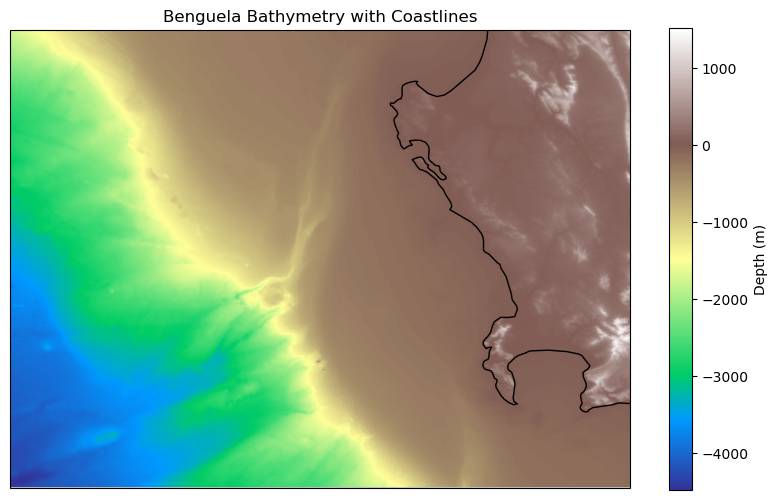

In [77]:
# Open bathymetry file
with rasterio.open("benguela_bathymetry.grd") as src:
    bathy = src.read(1)
    bounds = src.bounds

# Create coordinate grid
rows, cols = bathy.shape
x = np.linspace(bounds.left, bounds.right, cols)
y = np.linspace(bounds.bottom, bounds.top, rows)
X, Y = np.meshgrid(x, y)

# Define study region (Benguela)
lon_min, lon_max = 15.9104, 19.0613
lat_min, lat_max = -34.7723, -32.4412

# Mask to region only 
bathy_region = np.where(
    (X >= lon_min) & (X <= lon_max) &
    (Y >= lat_min) & (Y <= lat_max),
    bathy,
    np.nan)

# Create figure with map projection
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot bathymetry
im = ax.imshow(
    bathy_region,
    cmap="terrain",
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="upper",
    transform=ccrs.PlateCarree())

# Add coastlines
ax.coastlines(resolution="10m", linewidth=1)

# Land fill
ax.add_feature(cfeature.LAND, color="lightgray")

# Set map extent explicitly
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add colorbar
plt.colorbar(im, ax=ax, label="Depth (m)")

# Title
ax.set_title("Benguela Bathymetry with Coastlines")

# Display figure
plt.show()

### 2. Loading a map of the mean annual chlorophyll in the lower Benguela region, using the "viridis" colormap.

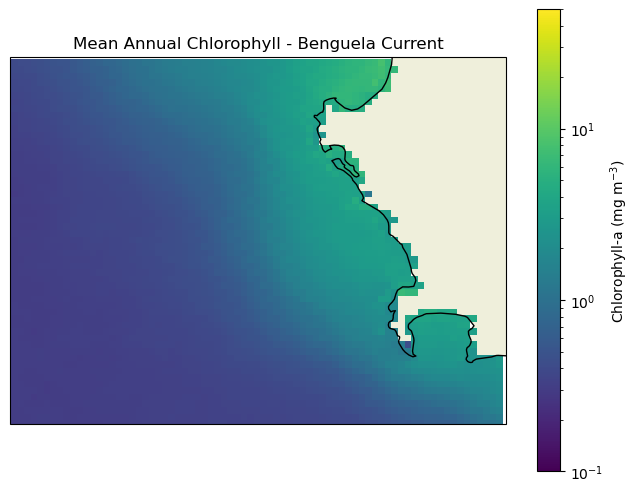

In [74]:
# Create a new figure
fig = plt.figure(figsize=(8,6))

# Create map axes 
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot chlorophyll data on the map
chl_mean.plot(
    
    # Tell cartopy the data are in geographic coordinates
    transform=ccrs.PlateCarree(),
    
    # Colormap
    cmap='viridis',
    
    # Logarithmic scaling for chlorophyll
    norm=colors.LogNorm(vmin=0.1, vmax=50),
    
    # Add colorbar label
    cbar_kwargs={'label': 'Chlorophyll-a (mg m$^{-3}$)'})

# Add coastlines
ax.coastlines(resolution='10m')

# Add land shading
ax.add_feature(cfeature.LAND)

# Add country borders
ax.add_feature(cfeature.BORDERS)

# Set map extent to Benguela region
ax.set_extent([15.9104, 19.0613, -34.7723, -32.4412])

# Add plot title
plt.title("Mean Annual Chlorophyll - Benguela Current")

# Display the figure
plt.show()

### 3. Loading a faceted figure of the monthly average chlorophyll-a, showing 12 maps, one for each month. We chose the "turbo" colormap in order to contrast the upwelling areas well from the open ocean.

/var/folders/sh/4ztnqrp512s6g4rxqrcpmwb80000gp/T/ipykernel_56596/2341141254.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


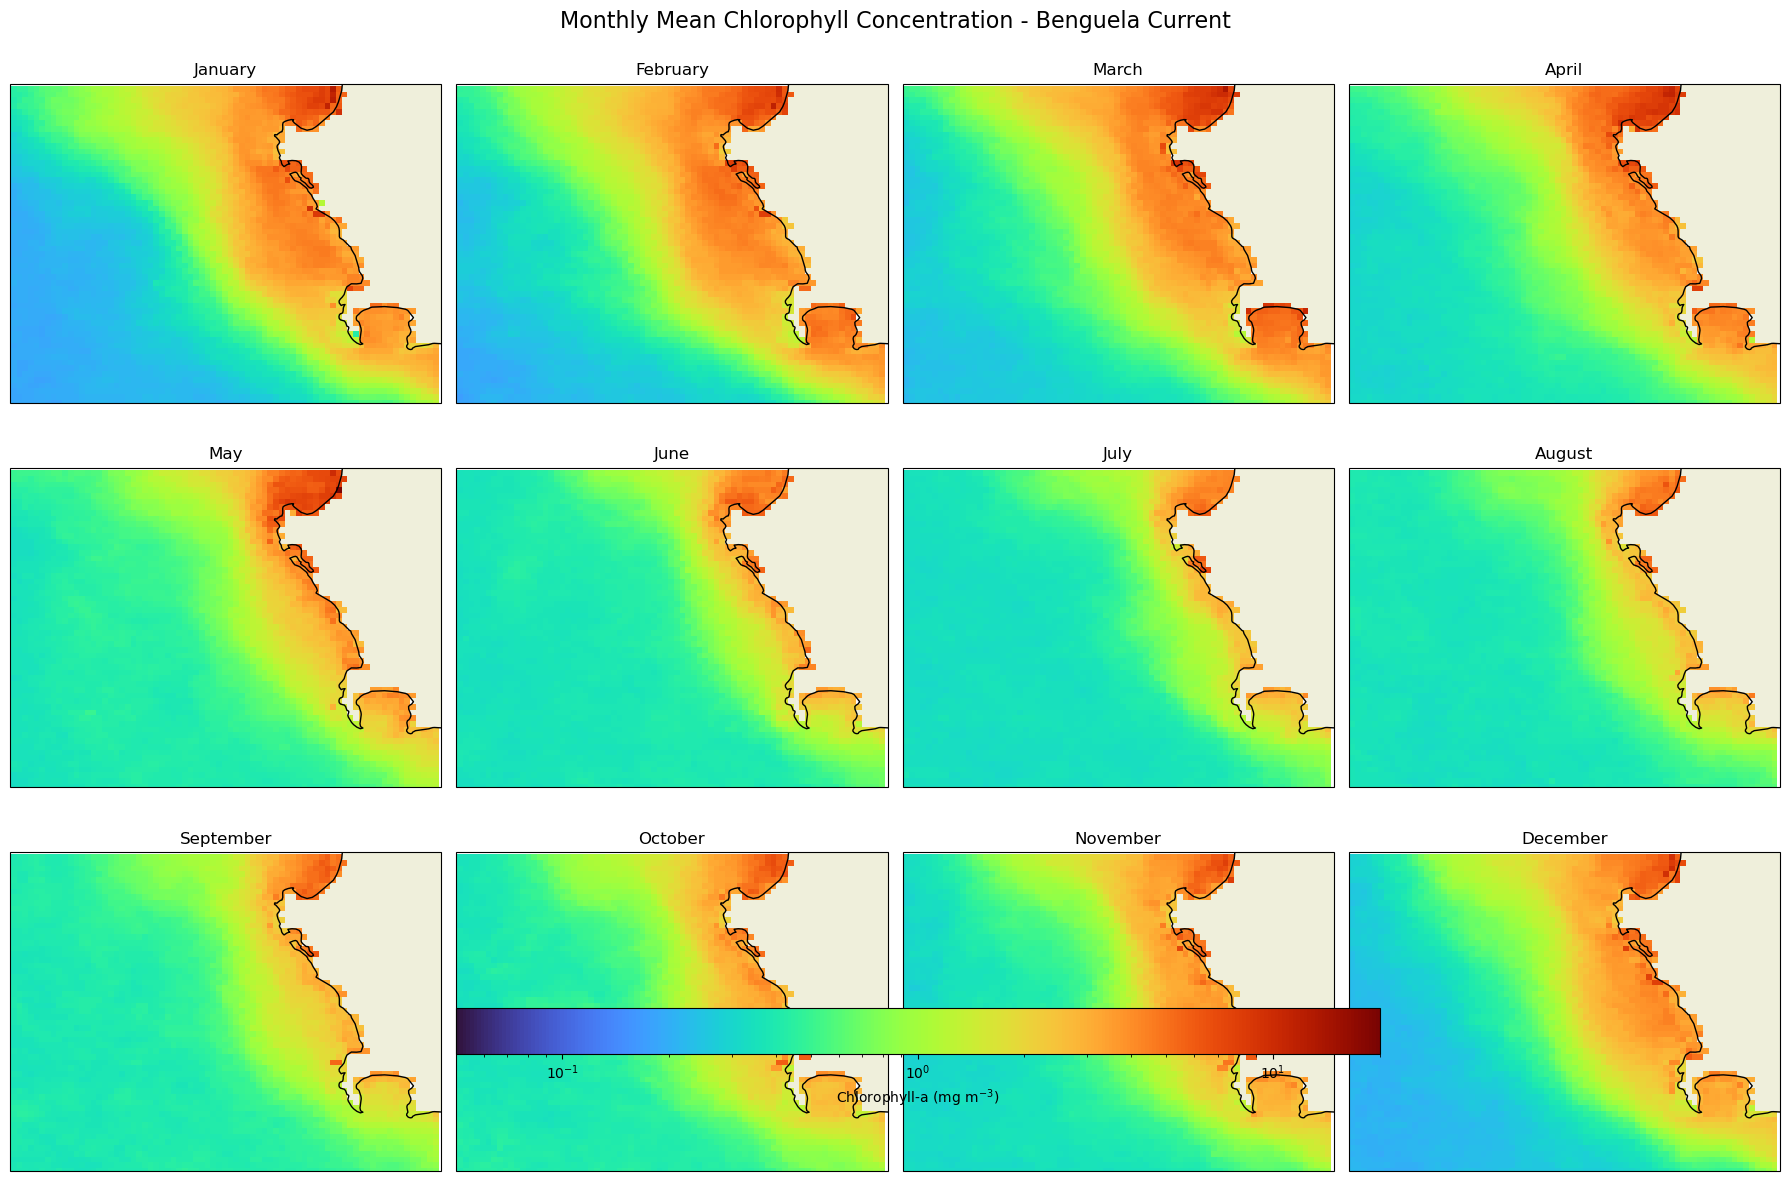

In [75]:
# Open the chlorophyll dataset
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Subset to the Benguela Current region - latitude order is reversed because many oceanographic datasets store latitude from north to south
subset = ds.sel(
    lon=slice(15.9104, 19.0613),
    lat=slice(-32.4412, -34.7723))

# Extract chlorophyll variable
chl = subset['chlor_a']

# Remove invalid values
chl = chl.where(chl > 0)

# Group data by month and compute monthly mean
monthly_mean = chl.groupby("time.month").mean()

# Create a figure with 12 subplots (3 rows x 4 columns)
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes array so we can loop through easily
axes = axes.flatten()

# Define month names for titles
month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"]

# Loop through all 12 months
for i in range(12):
    
    # Select the current subplot axis
    ax = axes[i]
    
    # Select chlorophyll data for current month
    data = monthly_mean.sel(month=i+1)
    
    # Plot the monthly chlorophyll map
    im = data.plot(
        
        # Plot on current axis
        ax=ax,
        
        # Coordinate reference system
        transform=ccrs.PlateCarree(),
        
        # Colormap
        cmap='turbo',
        
        # Log scale improves visibility of ocean productivity patterns
        norm=colors.LogNorm(vmin=0.05, vmax=20),
        
        # Turn off automatic colorbar creation
        add_colorbar=False)
    
    # Add coastline
    ax.coastlines(resolution='10m')
    
    # Add land feature
    ax.add_feature(cfeature.LAND)
    
    # Set geographic extent
    ax.set_extent([15.9104, 19.0613, -34.7723, -32.4412])
    
    # Add subplot title
    ax.set_title(month_names[i])

# Create one shared colorbar for all subplots
cbar = fig.colorbar(
    
    # Use the plotted image object
    im,
    
    # Apply to all subplot axes
    ax=axes,
    
    # Orientation of colorbar
    orientation='horizontal',
    
    # Size and spacing controls
    fraction=0.05,
    pad=0.05)

# Add colorbar label
cbar.set_label("Chlorophyll-a (mg m$^{-3}$)")

# Add figure title
fig.suptitle(
    "Monthly Mean Chlorophyll Concentration - Benguela Current",
    fontsize=16)

# Improve spacing between plots
plt.tight_layout()

# Display figure
plt.show()

/var/folders/sh/4ztnqrp512s6g4rxqrcpmwb80000gp/T/ipykernel_56596/2691006278.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


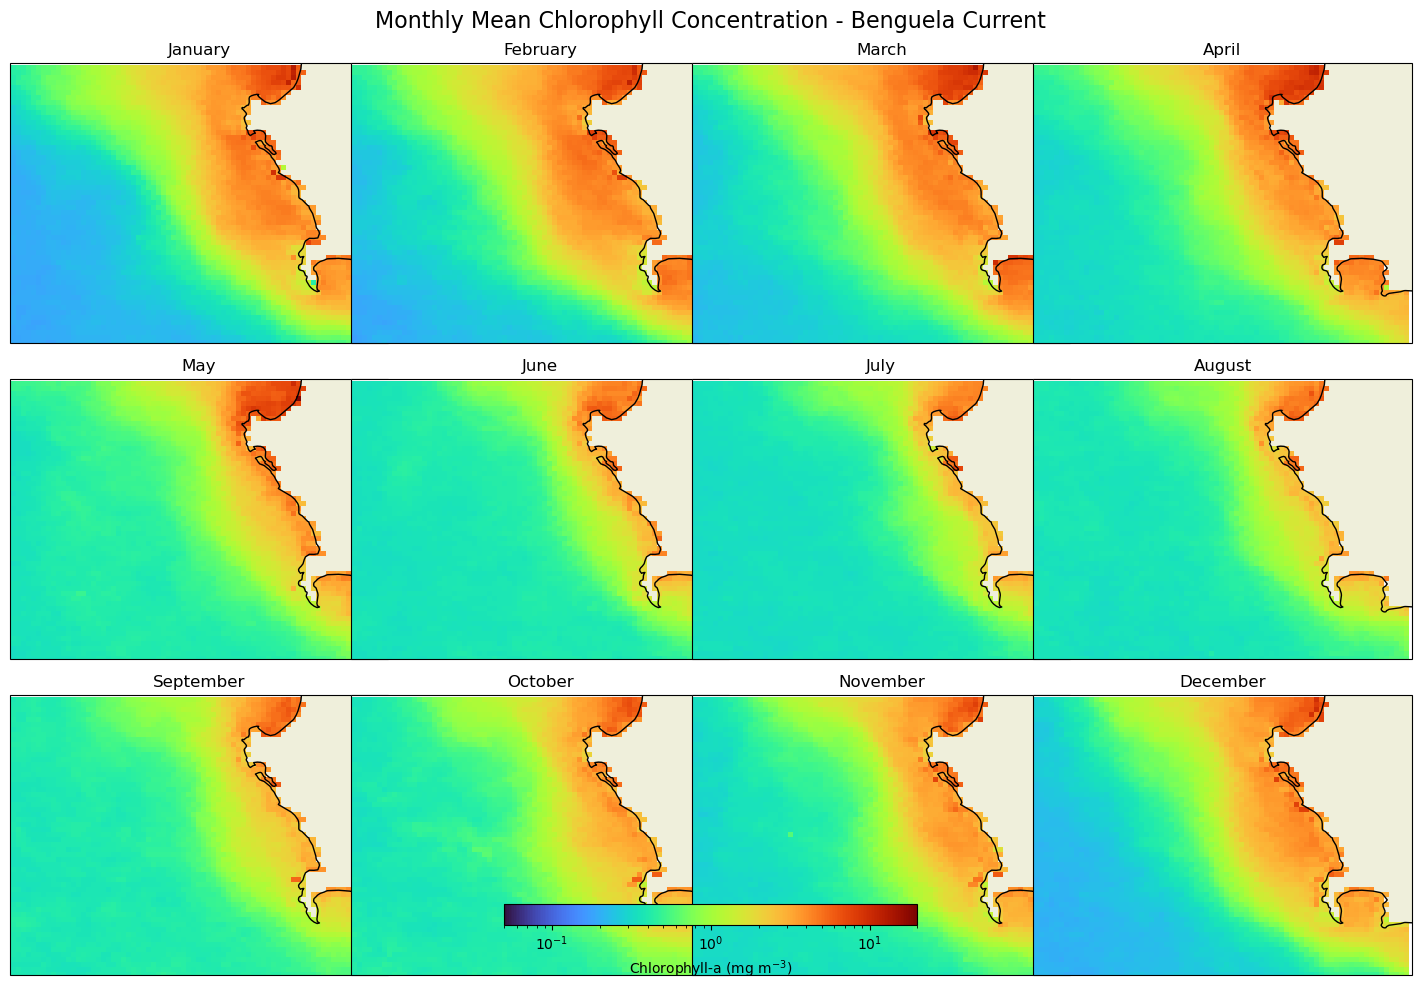

In [101]:
# Open the chlorophyll dataset
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Subset to the Benguela Current region - latitude order is reversed because many oceanographic datasets store latitude from north to south
subset = ds.sel(
    lon=slice(15.9104, 19.0613),
    lat=slice(-32.4412, -34.7723))

# Extract chlorophyll variable
chl = subset['chlor_a']

# Remove invalid values
chl = chl.where(chl > 0)

# Group data by month and compute monthly mean
monthly_mean = chl.groupby("time.month").mean()

# Create a figure with 12 subplots (3 rows x 4 columns)
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes array so we can loop through easily
axes = axes.flatten()

# Define month names for titles
month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"]

# Loop through all 12 months
for i in range(12):
    
    # Select the current subplot axis
    ax = axes[i]
    
    # Select chlorophyll data for current month
    data = monthly_mean.sel(month=i+1)
    
    # Plot the monthly chlorophyll map
    im = data.plot(
        
        # Plot on current axis
        ax=ax,
        
        # Coordinate reference system
        transform=ccrs.PlateCarree(),
        
        # Colormap
        cmap='turbo',
        
        # Log scale improves visibility of ocean productivity patterns
        norm=colors.LogNorm(vmin=0.05, vmax=20),
        
        # Turn off automatic colorbar creation
        add_colorbar=False)
    
    # Add coastline
    ax.coastlines(resolution='10m')
    
    # Add land feature
    ax.add_feature(cfeature.LAND)
    
    # Set geographic extent
    ax.set_extent([15.9104, 19.0613, -34.7723, -32.4412])
    
    # Add subplot title
    ax.set_title(month_names[i])



# Improve spacing between plots, but reserve space at the bottom
plt.tight_layout(rect=[0, 0.05, 1, 0.5])

# Create one shared colorbar below all subplots
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05
)

cbar.set_label("Chlorophyll-a (mg m$^{-3}$)")



# Add figure title
fig.suptitle(
    "Monthly Mean Chlorophyll Concentration - Benguela Current",
    fontsize=16)

# Improve spacing between plots
plt.tight_layout()

# Display figure
plt.show()

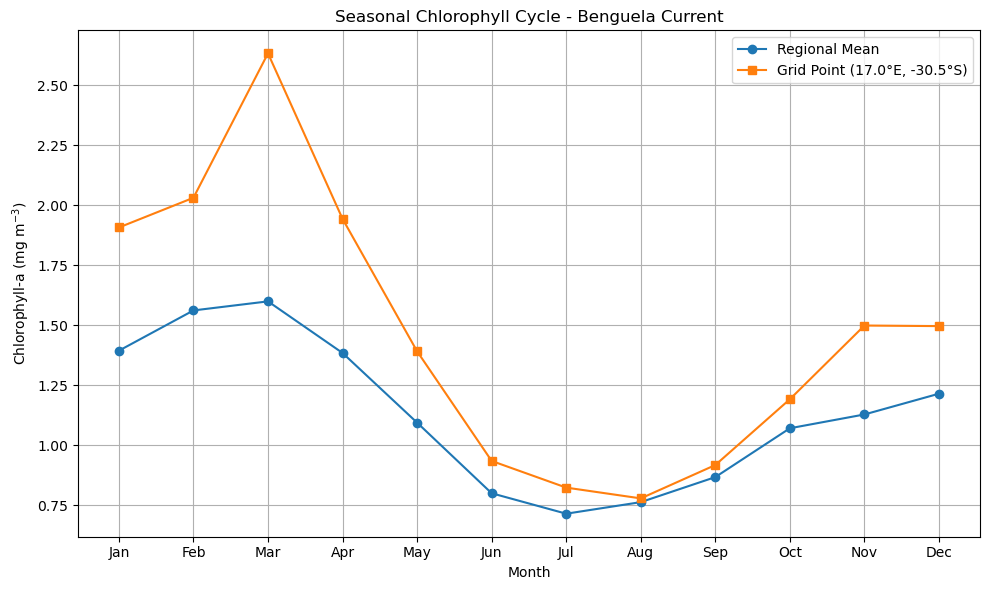

In [102]:
# Open the chlorophyll dataset
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Subset to Benguela Current region
subset = ds.sel(
    lon=slice(15.9104, 19.0613),
    lat=slice(-32.4412, -34.7723))

# Extract chlorophyll variable
chl = subset['chlor_a']

# Remove invalid values
chl = chl.where(chl > 0)

# 1. Calculate regional mean seasonal cycle

# Compute spatial mean across all latitude and longitude points
regional_mean = chl.mean(dim=['lat', 'lon'])

# 2. Select a single high-chlorophyll grid point

# Comparison point: Namaqualand upwelling zone (strong seasonal bloom)
point_lat = -30.5
point_lon = 17.0

# Extract nearest grid cell to chosen coordinates
point_series = chl.sel(
    lat=point_lat,
    lon=point_lon,
    method='nearest')

# 3. Create month labels
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"]

# Create x-axis values (1–12)
months = np.arange(1, 13)

# 4. Create timeseries plot

# Create figure
plt.figure(figsize=(10,6))

# Plot regional mean seasonal cycle
plt.plot(
    months,
    regional_mean,
    marker='o',
    label='Regional Mean')

# Plot single grid-point seasonal cycle
plt.plot(
    months,
    point_series,
    marker='s',
    label=f'Grid Point ({point_lon}°E, {point_lat}°S)')

# 5. Customize plot

# Set x-axis labels
plt.xticks(months, month_names)

# Axis labels
plt.xlabel("Month")
plt.ylabel("Chlorophyll-a (mg m$^{-3}$)")

# Add title
plt.title("Seasonal Chlorophyll Cycle - Benguela Current")

# Add grid lines
plt.grid(True)

# Add legend
plt.legend()

# Improve spacing
plt.tight_layout()


# Display plot
plt.show()